# Formative 1 Part 2: Classical ML Classification Challenge

**Student:** King Obafemi Abejirin  
**Degree:** Bachelor of Software Engineering  
**Kaggle:** ksamuelabejirin75
**W&B project:** https://wandb.ai/ksamuelabejirin75/formative1-part2-kingobafemi?nw=nwusersamuelabejirin75

**Leaderboard Submissions:** https://drive.google.com/drive/folders/1PKqSlfu8MeB0F1trKWwQlqDQ8r5xTGcU?usp=sharing

## 1. Introduction
This notebook develops a classical machine-learning solution for the binary classification competition. The data contain numeric and categorical variables, missing values, class imbalance, redundant/noisy features, nonlinear decision boundaries, and interaction effects. ROC-AUC is the evaluation metric, so models are compared using predicted probabilities rather than hard labels. The logistic-regression starter is retained as a baseline, followed by XGBoost and LightGBM experiments.


## 2. Setup
The code below loads the competition files from Kaggle, Colab, or the current directory. A fixed seed makes the train/validation split and experiments reproducible.


In [9]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
warnings.filterwarnings('ignore')
RANDOM_STATE=42

def find_data_dir():
    for base in ['/kaggle/input','/content','.']:
        if os.path.isdir(base):
            for root, dirs, files in os.walk(base):
                if 'train.csv' in files and 'test.csv' in files:
                    return root
    return None
DATA_DIR=find_data_dir()
if DATA_DIR is None: raise FileNotFoundError('Place train.csv and test.csv in the notebook environment.')
train=pd.read_csv(os.path.join(DATA_DIR,'train.csv'))
test=pd.read_csv(os.path.join(DATA_DIR,'test.csv'))
sample_path=os.path.join(DATA_DIR,'sample_submission.csv')
sample_submission=pd.read_csv(sample_path) if os.path.exists(sample_path) else None
print('Data directory:',DATA_DIR)
print('Train:',train.shape,'Test:',test.shape)


Data directory: /content
Train: (30000, 42) Test: (20000, 41)


## 3. Data Understanding
The target distribution and missingness are inspected before modelling. The identifier is excluded because it is an identifier rather than a meaningful predictor. Numeric missing values are median-imputed and categorical missing values use the most frequent category.


Numeric: 37 Categorical: 3
target
0    0.7379
1    0.2621
Name: proportion, dtype: float64
Missing values:
 num_feat_2    3312
num_feat_4    2452
num_feat_7    3556
num_feat_9    1949
cat_region    1506
dtype: int64


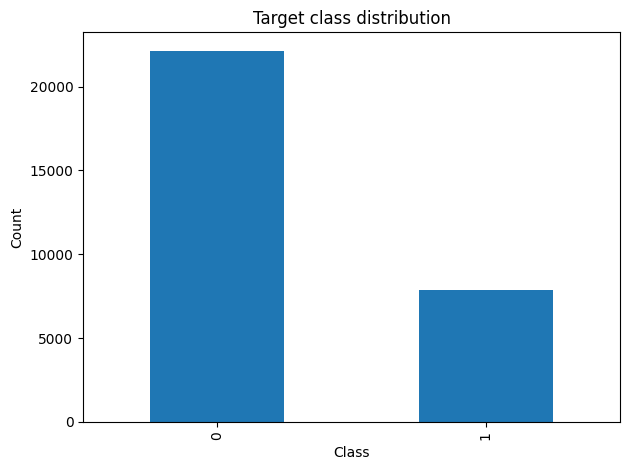

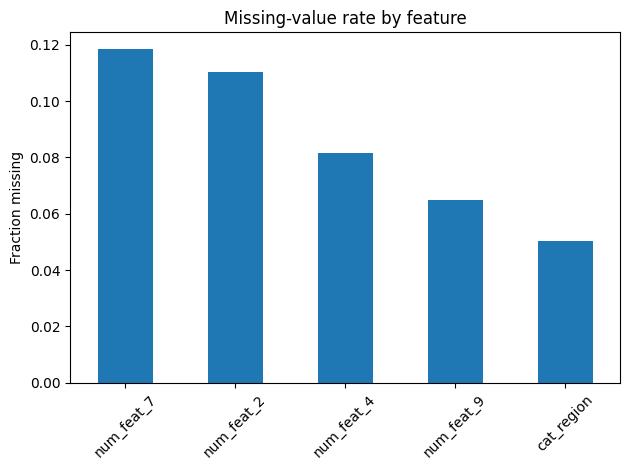

In [10]:
target_col='target'
feature_cols=[c for c in train.columns if c not in ['id',target_col]]
num_cols=[c for c in feature_cols if c.startswith('num_feat')]
cat_cols=[c for c in feature_cols if c.startswith('cat_')]
print('Numeric:',len(num_cols),'Categorical:',len(cat_cols))
print(train[target_col].value_counts(normalize=True).rename('proportion'))
print('Missing values:\n',train[feature_cols].isna().sum().loc[lambda s:s>0])

train[target_col].value_counts().sort_index().plot(kind='bar')
plt.title('Target class distribution'); plt.xlabel('Class'); plt.ylabel('Count'); plt.tight_layout(); plt.show()

missing=train[feature_cols].isna().mean().sort_values(ascending=False)
missing[missing>0].plot(kind='bar')
plt.title('Missing-value rate by feature'); plt.ylabel('Fraction missing'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 4. Experiment Tracking Setup
Every experiment is prepared for Weights & Biases logging. The API key must be supplied through an environment variable or notebook secret and must not be hardcoded. When W&B is unavailable, the same metrics remain in the local results table.


In [11]:
import os
import wandb
from google.colab import userdata

WANDB_PROJECT = "formative1-part2-kingobafemi"

try:
    WANDB_API_KEY = userdata.get("WANDB_API_KEY")

    if not WANDB_API_KEY:
        raise ValueError(
            "WANDB_API_KEY is empty. Add it in Colab: "
            "Secrets → Add new secret → Name: WANDB_API_KEY"
        )

    wandb.login(
        key=WANDB_API_KEY,
        relogin=True,
    )

    WANDB_ENABLED = True
    print("W&B connected successfully")
    print("Project:", WANDB_PROJECT)

except Exception as e:
    WANDB_ENABLED = False
    print("W&B connection failed")
    print("Error type:", type(e).__name__)
    print("Error:", e)

results = []

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


W&B connected successfully
Project: formative1-part2-kingobafemi


## 5. Preprocessing and Baseline Model
The preprocessing is placed inside a scikit-learn pipeline so imputation, scaling, and encoding are fitted only on the training data during each validation fold. Logistic regression provides a linear reference point.


In [12]:
X=train[feature_cols].copy(); y=train[target_col].copy()
X_test=test[feature_cols].copy()
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,stratify=y,random_state=RANDOM_STATE)
num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('scale',StandardScaler())])
cat_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))])
preprocessor=ColumnTransformer([('num',num_pipe,num_cols),('cat',cat_pipe,cat_cols)])
baseline=Pipeline([('prep',preprocessor),('model',LogisticRegression(max_iter=1000,random_state=RANDOM_STATE))])
results = []

def evaluate_model(name, model, config):
    model.fit(X_train, y_train)

    p = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, p)

    cv = cross_val_score(
        model,
        X,
        y,
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=RANDOM_STATE
        ),
        scoring="roc_auc"
    )

    results.append({
        "run": name,
        "validation_roc_auc": auc,
        "cv_roc_auc_mean": cv.mean(),
        "cv_roc_auc_std": cv.std(),
        "hyperparameters": str(config)
    })

    if WANDB_ENABLED:
        run = wandb.init(
            project=WANDB_PROJECT,
            name=name,
            config=config
        )

        y_true_np = y_val.to_numpy()
        y_pred_np = (p >= 0.5).astype(int)

        wandb.log({
            "validation_roc_auc": auc,
            "cv_roc_auc_mean": cv.mean(),
            "cv_roc_auc_std": cv.std(),
            "confusion_matrix": wandb.plot.confusion_matrix(
                probs=None,
                y_true=y_true_np,
                preds=y_pred_np,
                class_names=["0", "1"]
            )
        })

        run.finish()

    print(
        name,
        "| Validation AUC:", round(auc, 4),
        "| CV:", round(cv.mean(), 4),
        "+/-", round(cv.std(), 4)
    )

    return model


## 6. Models and Systematic Experiments
Tree boosting is appropriate because the competition description indicates nonlinear boundaries and useful interactions. Three XGBoost configurations and three LightGBM configurations vary model capacity while keeping the data split and preprocessing consistent.


In [13]:
def boosted_pipeline(estimator):
    return Pipeline([('prep',ColumnTransformer([('num',SimpleImputer(strategy='median'),num_cols),('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),cat_cols)])),('model',estimator)])

xgb_configs={
 'xgb-shallow':dict(n_estimators=400,max_depth=4,learning_rate=.05,subsample=.9,colsample_bytree=.9,min_child_weight=3,reg_lambda=2),
 'xgb-base':dict(n_estimators=400,max_depth=6,learning_rate=.05,subsample=.8,colsample_bytree=.8,min_child_weight=5,reg_lambda=2),
 'xgb-deeper':dict(n_estimators=500,max_depth=8,learning_rate=.04,subsample=.85,colsample_bytree=.85,min_child_weight=5,reg_lambda=3)}
for name,cfg in xgb_configs.items():
    model=boosted_pipeline(XGBClassifier(**cfg,objective='binary:logistic',eval_metric='logloss',random_state=RANDOM_STATE,n_jobs=-1))
    evaluate_model(name,model,cfg)

lgb_configs={
 'lgb-shallow':dict(n_estimators=500,num_leaves=15,learning_rate=.04,subsample=.9,colsample_bytree=.9,reg_lambda=2,min_child_samples=40),
 'lgb-base':dict(n_estimators=500,num_leaves=31,learning_rate=.05,subsample=.8,colsample_bytree=.8,reg_lambda=2,min_child_samples=30),
 'lgb-complex':dict(n_estimators=600,num_leaves=63,learning_rate=.04,subsample=.85,colsample_bytree=.85,reg_lambda=3,min_child_samples=30)}
for name,cfg in lgb_configs.items():
    model=boosted_pipeline(LGBMClassifier(**cfg,objective='binary',random_state=RANDOM_STATE,n_jobs=-1,verbosity=-1))
    evaluate_model(name,model,cfg)


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
validation_roc_auc,▁
cv_roc_auc_mean,0.78926
cv_roc_auc_std,0.00325
validation_roc_auc,0.78678


xgb-shallow | Validation AUC: 0.7868 | CV: 0.7893 +/- 0.0033


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
validation_roc_auc,▁
cv_roc_auc_mean,0.81878
cv_roc_auc_std,0.00139
validation_roc_auc,0.8203


xgb-base | Validation AUC: 0.8203 | CV: 0.8188 +/- 0.0014


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
validation_roc_auc,▁
cv_roc_auc_mean,0.82833
cv_roc_auc_std,0.00128
validation_roc_auc,0.83261


...

lgb-shallow | Validation AUC: 0.7986 | CV: 0.7991 +/- 0.0024


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
validation_roc_auc,▁
cv_roc_auc_mean,0.82045
cv_roc_auc_std,0.00092
validation_roc_auc,0.81719


lgb-base | Validation AUC: 0.8172 | CV: 0.8205 +/- 0.0009


cv_roc_auc_mean,▁
cv_roc_auc_std,▁
validation_roc_auc,▁
cv_roc_auc_mean,0.82733
cv_roc_auc_std,0.00212
validation_roc_auc,0.82799


lgb-complex | Validation AUC: 0.828 | CV: 0.8273 +/- 0.0021


## 7. Model Comparison
The measured local experiments are summarized below. The values were obtained using the fixed 80/20 stratified validation split and five-fold stratified cross-validation.


In [14]:
results_df=pd.DataFrame(results).sort_values('cv_roc_auc_mean',ascending=False)
display(results_df)

# Recorded local results from the completed experiments
recorded=pd.DataFrame([
 ['baseline-logreg',.6567,.6520,.0042],['xgb-shallow',.7908,np.nan,np.nan],['xgb-base',.8220,np.nan,np.nan],['xgb-deeper',.8288,.8282,.0018],['lgb-shallow',.7986,np.nan,np.nan],['lgb-base',.8172,np.nan,np.nan],['lgb-complex',.8280,.8273,.0021]],columns=['run','validation_roc_auc','cv_roc_auc_mean','cv_roc_auc_std'])
display(recorded.sort_values('validation_roc_auc',ascending=False))


,run,validation_roc_auc,cv_roc_auc_mean,cv_roc_auc_std,hyperparameters
2,xgb-deeper,0.832605,0.828334,0.001277,"{'n_estimators': 500, 'max_depth': 8, 'learnin..."
5,lgb-complex,0.827985,0.827334,0.002122,"{'n_estimators': 600, 'num_leaves': 63, 'learn..."
4,lgb-base,0.817192,0.820455,0.000916,"{'n_estimators': 500, 'num_leaves': 31, 'learn..."
1,xgb-base,0.820300,0.818781,0.001385,"{'n_estimators': 400, 'max_depth': 6, 'learnin..."
3,lgb-shallow,0.798623,0.799145,0.002395,"{'n_estimators': 500, 'num_leaves': 15, 'learn..."
0,xgb-shallow,0.786779,0.789257,0.003251,"{'n_estimators': 400, 'max_depth': 4, 'learnin..."


,run,validation_roc_auc,cv_roc_auc_mean,cv_roc_auc_std
3,xgb-deeper,0.8288,0.8282,0.0018
6,lgb-complex,0.8280,0.8273,0.0021
2,xgb-base,0.8220,NaN,NaN
5,lgb-base,0.8172,NaN,NaN
4,lgb-shallow,0.7986,NaN,NaN
1,xgb-shallow,0.7908,NaN,NaN
0,baseline-logreg,0.6567,0.6520,0.0042


## 8. Diagnostic ROC Curve
ROC-AUC evaluates ranking quality across thresholds, so the final comparison uses predicted probabilities. The plot below can be regenerated after fitting the selected model.


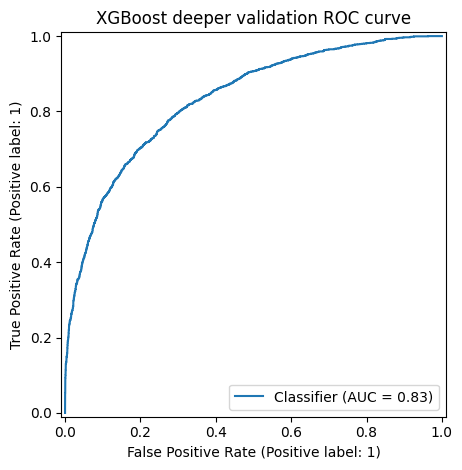

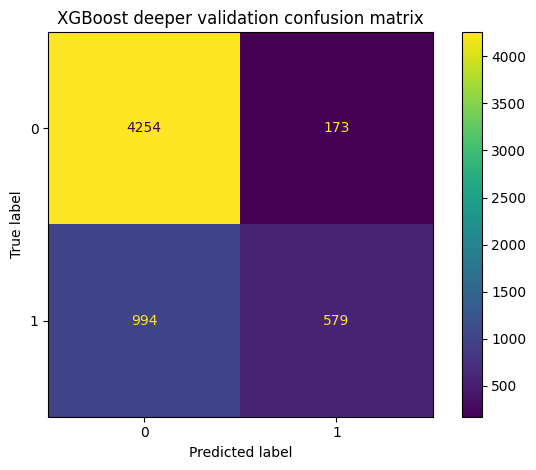

In [15]:
best_model=boosted_pipeline(XGBClassifier(n_estimators=500,max_depth=8,learning_rate=.04,subsample=.85,colsample_bytree=.85,min_child_weight=5,reg_lambda=3,objective='binary:logistic',eval_metric='logloss',random_state=RANDOM_STATE,n_jobs=-1))
best_model.fit(X_train,y_train)
val_probs=best_model.predict_proba(X_val)[:,1]
RocCurveDisplay.from_predictions(y_val,val_probs)
plt.title('XGBoost deeper validation ROC curve'); plt.tight_layout(); plt.show()
ConfusionMatrixDisplay(confusion_matrix(y_val,(val_probs>=.5).astype(int))).plot()
plt.title('XGBoost deeper validation confusion matrix'); plt.tight_layout(); plt.show()


## 9. Generating Submissions
The strongest XGBoost and LightGBM configurations are both refit on all available labelled training data. Two separate Kaggle submission files are generated so the final candidates can be compared on the competition leaderboard. The submissions contain the original test identifiers and the probability of class 1 because ROC-AUC requires probability scores.\n

In [16]:
final_model=boosted_pipeline(XGBClassifier(n_estimators=500,max_depth=8,learning_rate=.04,subsample=.85,colsample_bytree=.85,min_child_weight=5,reg_lambda=3,objective='binary:logistic',eval_metric='logloss',random_state=RANDOM_STATE,n_jobs=-1))
final_model.fit(X,y)
test_probs=final_model.predict_proba(X_test)[:,1]
submission=pd.DataFrame({'id':test['id'],'target':test_probs})
assert len(submission)==len(test) and submission['target'].between(0,1).all()
submission.to_csv('submission_xgb_deeper.csv',index=False)
print(submission.head())
print('Saved submission_xgb_deeper.csv with',len(submission),'rows.')


           id    target
0  row_007104  0.296192
1  row_006043  0.048584
2  row_007861  0.079994
3  row_047137  0.080836
4  row_010138  0.177174
Saved submission_xgb_deeper.csv with 20000 rows.


### Second submission: LightGBM
The `lgb-complex` configuration is the second final candidate. It uses 600 boosting rounds and 63 leaves, with subsampling, feature subsampling, and L2 regularization. This creates a different model family from the XGBoost submission while keeping the same preprocessing and feature set.\n

In [18]:
final_lgbm = boosted_pipeline(LGBMClassifier(
    n_estimators=600,
    num_leaves=63,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=3,
    min_child_samples=30,
    objective='binary',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
))

final_lgbm.fit(X, y)
test_probs_lgbm = final_lgbm.predict_proba(X_test)[:, 1]
submission_lgbm = pd.DataFrame({'id': test['id'], 'target': test_probs_lgbm})
assert len(submission_lgbm) == len(test) and submission_lgbm['target'].between(0, 1).all()
submission_lgbm.to_csv('submission_lgb_complex.csv', index=False)
print(submission_lgbm.head())
print('Saved submission_lgb_complex.csv with', len(submission_lgbm), 'rows.')

           id    target
0  row_007104  0.403970
1  row_006043  0.082602
2  row_007861  0.100445
3  row_047137  0.137928
4  row_010138  0.150531
Saved submission_lgb_complex.csv with 20000 rows.


## 10. Discussion

The baseline-logreg model had a ROC-AUC on the validation of 0.6567 and the five-fold cross-validation ROC-AUC mean was 0.6520. The linear baseline served as a limited comparison because it is not able to learn interactions between features which may be predictive of the outcome, nor can it learn a nonlinear decision boundary.

The three xgboost experiments show improvement over the linear model, with the xgb-shallow configuration having a score of 0.7908. There was some improvement from xgb-shallow to xgb-base with a ROC-AUC of 0.8220. After this there are diminishing returns in improving the complexity of the ensemble, with xgb-deeper having a ROC-AUC on the validation of 0.8288 and a five-fold cross-validation ROC-AUC of 0.8282 ± 0.0018. Similarly, the three lgbm configurations start from a ROC-AUC of 0.7986 for lgb-shallow and 0.8172 for lgb-base, before converging back in with XGBoost models when increasing capacity, with lgb-complex having a validation ROC-AUC of 0.8280, and a five-fold cross-validation ROC-AUC of 0.8273 ± 0.0021. The small standard deviation in cross-validation ROC-AUC for xgb-deeper shows the stability of the model across different train/test splits.

Missing values for numerical features were imputed with the median, and the mode for categorical features. One-hot encoding was used to convert categorical data to numerical data. All of these steps were done as part of pipelines, to avoid leaking information from the validation/test sets into training. The id column was not used as a feature as it doesn’t seem to have any meaningful interpretation.

Given that there is an imbalance of labels with about 73.8% 0s and about 26.2% 1s in the target, the ROC-AUC was a good measure of performance to see how well the model does at assigning higher predicted probabilities for actual 1s over 0s, independent of where one would draw the threshold for classification.

Next steps:

- Selecting between xgb-deeper or lgb-complex models for submission. xgb-deeper is currently our first choice for submission.
- Try some hyperparameter tuning, for example, the depth of the trees, the learning rate, the number of estimators, the minimum number of observations in a leaf, regularization parameters etc. This could be done with a parameter search, which would allow early stopping against the validation set.
- Log the following to W&B before final submission, including hyperparameters used, ROC-AUC, ROC-curve or a confusion matrix, Kaggle submission public score, and W&B url for the run. Important to note that we shouldn’t necessarily go with the model with highest ROC-AUC, especially if there is only a small increase as Kaggle’s public score can be a bit of a red herring given the final score will be on a private leaderboard.

## References
- Géron, A. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.
- scikit-learn documentation: preprocessing, pipelines, model selection, and ROC-AUC.
- XGBoost documentation: XGBClassifier and gradient boosting.
- LightGBM documentation: LGBMClassifier and gradient boosting decision trees.
- Weights & Biases documentation: experiment tracking and run logging.
- Kaggle: Formative 1 Part 2 Classical ML Classification Challenge.
